# Cross-Validation: U-Net Segmentation & the Full Fusion Pipeline

Two separate cross-validation studies, run manually (this is a long-running notebook — see
the config cell for how to control total runtime):

**Part A — U-Net segmentation CV.** Retrains U-Net from scratch across `K_FOLDS` stratified
folds (by growth stage) carved from train+valid (822 images), evaluating **pixel-level
binary classification metrics** (precision, recall, F1, accuracy — leaf vs. background) on
each fold's held-out subset AND on the fixed, never-touched `processed/test` set (160
images). This isolates: how much does U-Net's segmentation quality vary depending on which
images it happened to train on?

**Part B — Fusion pipeline CV.** For each fold's U-Net checkpoint from Part A, runs the full
segment→mask→classify pipeline against the fixed `processed/test` set, using the
**already-trained, fixed** masked-ResNet50 classifier from the sibling project (not
retrained here). Evaluates **4-class classification metrics** (precision, recall, F1,
accuracy per growth stage) for each fold's U-Net.

**Scope decision, stated explicitly:** only the segmenter varies across folds; the
classifier is reused unchanged. Retraining the classifier per fold too would require
importing its masked-image training pipeline from the separate ResNet50 project (a bigger,
cross-project change) — this design isolates the segmenter's contribution to pipeline
robustness instead. Extending Part B to retrain the classifier per fold as well is a
reasonable next step if full end-to-end pipeline CV is needed later.

**Nothing here touches** `unet_pipeline.ipynb`'s own `checkpoints/unet_best.pth` or
`export/` — fold checkpoints are saved separately under `checkpoints/cv_folds/`.


## Setup

In [16]:
import os
import json
import random

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from tqdm.auto import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [17]:
# --- paths ---
UNET_PROJECT_ROOT = r"d:/Reasearch/Unet"
PROCESSED_DIR = os.path.join(UNET_PROJECT_ROOT, "processed")
CV_CHECKPOINT_DIR = os.path.join(UNET_PROJECT_ROOT, "checkpoints", "cv_folds")
CV_OUTPUT_DIR = os.path.join(UNET_PROJECT_ROOT, "outputs", "cross_validation")
os.makedirs(CV_CHECKPOINT_DIR, exist_ok=True)
os.makedirs(CV_OUTPUT_DIR, exist_ok=True)

# fixed, external, already-trained classifier -- never retrained in this notebook
RESNET_PROJECT_ROOT = r"d:/Reasearch/Resnet50test"
CLASSIFIER_CKPT_PATH = os.path.join(RESNET_PROJECT_ROOT, "checkpoints_masked", "resnet50_masked_best.pt")
assert os.path.exists(CLASSIFIER_CKPT_PATH), f"missing: {CLASSIFIER_CKPT_PATH}"

# --- CV config -- ADJUST THESE to trade off runtime vs. rigor ---
K_FOLDS = 5                 # stratified by growth_stage
EPOCHS_PER_FOLD = 30         # bumped from 8 -- that run undertrained badly (best_val_dice ~0.39 vs
                             # the main single-split model's 0.81); main pipeline itself uses 60
IMG_SIZE = 224
BASE_CHANNELS = 32
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
NUM_WORKERS = 0              # Windows/Jupyter DataLoader workers hang -- keep at 0, see unet_pipeline.ipynb
MASK_THRESHOLD = 0.5

CLASS_NAMES = ["developing", "flowering", "fruiting", "seeding"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print(f"Part A will train {K_FOLDS} U-Net models x {EPOCHS_PER_FOLD} epochs "
      f"({K_FOLDS * EPOCHS_PER_FOLD} total epochs, vs. 60 for one full training run).")

Part A will train 5 U-Net models x 30 epochs (150 total epochs, vs. 60 for one full training run).


## Part A — U-Net Segmentation Cross-Validation

### Build the fold pool

Combines `processed/train` + `processed/valid` (822 images total) into one pool that gets
re-split into folds. `processed/test` (160 images) is never part of any fold — held out
exactly like in the main training notebook, used only for the fixed-test-set evaluation
below.

In [18]:
def load_split_as_df(split, images_subdir="images", masks_subdir="masks"):
    df = pd.read_csv(os.path.join(PROCESSED_DIR, split, "stage_mapping.csv"))
    df["image_path"] = df["filename"].apply(lambda f: os.path.join(PROCESSED_DIR, split, images_subdir, f))
    df["mask_path"] = df["mask_filename"].apply(lambda f: os.path.join(PROCESSED_DIR, split, masks_subdir, f))
    return df[["image_path", "mask_path", "growth_stage"]]

pool_df = pd.concat([load_split_as_df("train"), load_split_as_df("valid")], ignore_index=True)
fixed_test_df = load_split_as_df("test")

print(f"CV pool (train+valid): {len(pool_df)} images")
print(f"fixed held-out test:   {len(fixed_test_df)} images (never used for training or fold validation)")
print(pool_df["growth_stage"].value_counts())


CV pool (train+valid): 822 images
fixed held-out test:   160 images (never used for training or fold validation)
growth_stage
seeding       340
flowering     240
developing    162
fruiting       80
Name: count, dtype: int64


In [19]:
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
pool_df = pool_df.reset_index(drop=True)
pool_df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(pool_df, pool_df["growth_stage"])):
    pool_df.loc[val_idx, "fold"] = fold_idx

print(pool_df.groupby(["fold", "growth_stage"]).size().unstack(fill_value=0))


growth_stage  developing  flowering  fruiting  seeding
fold                                                  
0                     33         48        16       68
1                     33         48        16       68
2                     32         48        16       68
3                     32         48        16       68
4                     32         48        16       68


### Model, loss, and pixel-level metrics (same U-Net as unet_pipeline.ipynb)

In [20]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, base_channels=BASE_CHANNELS):
        super().__init__()
        c = base_channels
        self.enc1 = DoubleConv(in_channels, c)
        self.enc2 = DoubleConv(c, c * 2)
        self.enc3 = DoubleConv(c * 2, c * 4)
        self.enc4 = DoubleConv(c * 4, c * 8)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(c * 8, c * 16)
        self.up4 = nn.ConvTranspose2d(c * 16, c * 8, 2, stride=2)
        self.dec4 = DoubleConv(c * 16, c * 8)
        self.up3 = nn.ConvTranspose2d(c * 8, c * 4, 2, stride=2)
        self.dec3 = DoubleConv(c * 8, c * 4)
        self.up2 = nn.ConvTranspose2d(c * 4, c * 2, 2, stride=2)
        self.dec2 = DoubleConv(c * 4, c * 2)
        self.up1 = nn.ConvTranspose2d(c * 2, c, 2, stride=2)
        self.dec1 = DoubleConv(c * 2, c)
        self.out_conv = nn.Conv2d(c, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


def dice_coeff(probs, targets, eps=1e-6):
    probs = probs.reshape(probs.size(0), -1)
    targets = targets.reshape(targets.size(0), -1)
    intersection = (probs * targets).sum(dim=1)
    union = probs.sum(dim=1) + targets.sum(dim=1)
    return ((2 * intersection + eps) / (union + eps)).mean()


class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        dice_loss = 1 - dice_coeff(probs, targets)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


In [21]:
def pixel_classification_metrics(y_true, y_pred):
    """y_true, y_pred: flat 0/1 numpy arrays (any length). Returns a dict with precision/recall/F1
    for background (0) and leaf (1) separately, plus overall pixel accuracy."""
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1], zero_division=0)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "bg_precision": precision[0], "bg_recall": recall[0], "bg_f1": f1[0],
        "leaf_precision": precision[1], "leaf_recall": recall[1], "leaf_f1": f1[1],
    }


### Fold-aware segmentation dataset

In [22]:
class CVSegmentationDataset(Dataset):
    """Same preprocessing as unet_pipeline.ipynb's SegmentationDataset, but takes an explicit
    DataFrame of (image_path, mask_path) rows instead of a fixed split folder."""

    def __init__(self, df, img_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size
        self.augment = augment
        self.mean = np.array(IMAGENET_MEAN, dtype=np.float32)
        self.std = np.array(IMAGENET_STD, dtype=np.float32)

    def __len__(self):
        return len(self.df)

    def _augment_pair(self, img, mask):
        if random.random() < 0.5:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if random.random() < 0.5:
            img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        if random.random() < 0.5:
            k = random.choice([1, 2, 3])
            img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()
        return img, mask

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(row["mask_path"], cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
        mask = (mask > 127).astype(np.float32)

        if self.augment:
            img, mask = self._augment_pair(img, mask)

        img = img.astype(np.float32) / 255.0
        img = (img - self.mean) / self.std
        img = np.transpose(img, (2, 0, 1))

        img_t = torch.from_numpy(img.copy()).float()
        mask_t = torch.from_numpy(mask.copy()).float().unsqueeze(0)
        return img_t, mask_t, row["growth_stage"]


### Training loop (reused pattern from unet_pipeline.ipynb, with a live progress bar)

In [23]:
def run_epoch(model, loader, criterion, optimizer=None, scaler=None, desc="epoch"):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, total_dice, n_batches = 0.0, 0.0, 0

    pbar = tqdm(loader, desc=desc, leave=False)
    with torch.set_grad_enabled(is_train):
        for imgs, masks, _ in pbar:
            imgs, masks = imgs.to(device), masks.to(device)
            if is_train:
                optimizer.zero_grad()
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(imgs)
                    loss = criterion(logits, masks)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                    logits = model(imgs)
                    loss = criterion(logits, masks)

            probs = torch.sigmoid(logits).float()
            total_loss += loss.item()
            total_dice += dice_coeff(probs, masks).item()
            n_batches += 1
            pbar.set_postfix(loss=total_loss / n_batches, dice=total_dice / n_batches)

    return total_loss / n_batches, total_dice / n_batches


@torch.no_grad()
def collect_pixel_predictions(model, loader):
    """Runs model over loader, returns flat (y_true, y_pred) 0/1 pixel arrays for the whole set."""
    model.eval()
    all_true, all_pred = [], []
    for imgs, masks, _ in loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.sigmoid(logits)
        preds = (probs > MASK_THRESHOLD).float().cpu().numpy().astype(np.uint8)
        targets = masks.numpy().astype(np.uint8)
        all_true.append(targets.reshape(-1))
        all_pred.append(preds.reshape(-1))
    return np.concatenate(all_true), np.concatenate(all_pred)


### Run the CV loop

Trains one U-Net per fold from scratch, keeps the best-val-Dice checkpoint, then scores
pixel-level metrics on (a) that fold's own held-out subset and (b) the fixed external test
set. This is the long-running cell.

In [24]:
fixed_test_ds = CVSegmentationDataset(fixed_test_df, augment=False)
fixed_test_loader = DataLoader(fixed_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

fold_results = []

for fold in range(K_FOLDS):
    print(f"\n{'='*70}\nFOLD {fold + 1}/{K_FOLDS}\n{'='*70}")

    train_df = pool_df[pool_df["fold"] != fold]
    val_df = pool_df[pool_df["fold"] == fold]
    print(f"train={len(train_df)}  val={len(val_df)}")

    train_ds = CVSegmentationDataset(train_df, augment=True)
    val_ds = CVSegmentationDataset(val_df, augment=False)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = UNet(base_channels=BASE_CHANNELS).to(device)
    criterion = DiceBCELoss(bce_weight=0.5)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

    best_val_dice = 0.0
    fold_ckpt_path = os.path.join(CV_CHECKPOINT_DIR, f"unet_fold{fold}.pth")

    for epoch in range(1, EPOCHS_PER_FOLD + 1):
        train_loss, train_dice = run_epoch(model, train_loader, criterion, optimizer, scaler,
                                            desc=f"fold {fold+1} epoch {epoch}/{EPOCHS_PER_FOLD} [train]")
        val_loss, val_dice = run_epoch(model, val_loader, criterion,
                                        desc=f"fold {fold+1} epoch {epoch}/{EPOCHS_PER_FOLD} [val]")
        print(f"  epoch {epoch:02d}/{EPOCHS_PER_FOLD} | train dice {train_dice:.4f} | val dice {val_dice:.4f}")
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), fold_ckpt_path)

    # reload this fold's best checkpoint for evaluation
    model.load_state_dict(torch.load(fold_ckpt_path, map_location=device, weights_only=True))
    model.eval()

    y_true_val, y_pred_val = collect_pixel_predictions(model, val_loader)
    y_true_test, y_pred_test = collect_pixel_predictions(model, fixed_test_loader)

    val_metrics = pixel_classification_metrics(y_true_val, y_pred_val)
    test_metrics = pixel_classification_metrics(y_true_test, y_pred_test)

    print(f"  fold {fold+1} val-subset:  leaf F1={val_metrics['leaf_f1']:.4f}  acc={val_metrics['accuracy']:.4f}")
    print(f"  fold {fold+1} fixed-test:  leaf F1={test_metrics['leaf_f1']:.4f}  acc={test_metrics['accuracy']:.4f}")

    fold_results.append({
        "fold": fold, "best_val_dice": best_val_dice, "checkpoint": fold_ckpt_path,
        **{f"val_{k}": v for k, v in val_metrics.items()},
        **{f"test_{k}": v for k, v in test_metrics.items()},
    })

print("\nPart A complete.")



FOLD 1/5
train=657  val=165


C:\Users\KOSALA\AppData\Local\Temp\ipykernel_19632\2962508080.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))


fold 1 epoch 1/30 [train]:   0%|          | 0/83 [00:00<?, ?it/s]

C:\Users\KOSALA\AppData\Local\Temp\ipykernel_19632\1511684138.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


fold 1 epoch 1/30 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

...

fold 5 epoch 29/30 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 29/30 | train dice 0.7213 | val dice 0.7307


fold 5 epoch 30/30 [train]:   0%|          | 0/83 [00:00<?, ?it/s]

fold 5 epoch 30/30 [val]:   0%|          | 0/21 [00:00<?, ?it/s]

  epoch 30/30 | train dice 0.7308 | val dice 0.7380
  fold 5 val-subset:  leaf F1=0.7830  acc=0.9491
  fold 5 fixed-test:  leaf F1=0.7833  acc=0.9347

Part A complete.


### Part A summary

In [25]:
seg_cv_df = pd.DataFrame(fold_results)
seg_cv_df.to_csv(os.path.join(CV_OUTPUT_DIR, "unet_segmentation_cv_results.csv"), index=False)

print("=== Per-fold pixel-level metrics (fixed held-out test set) ===")
print(seg_cv_df[["fold", "test_accuracy", "test_leaf_precision", "test_leaf_recall", "test_leaf_f1"]]
      .to_string(index=False))

print("\n=== Mean +/- std across folds (fixed test set) ===")
for col in ["test_accuracy", "test_leaf_precision", "test_leaf_recall", "test_leaf_f1"]:
    print(f"  {col:22s} {seg_cv_df[col].mean():.4f} +/- {seg_cv_df[col].std():.4f}")

print("\n=== Mean +/- std across folds (each fold's own held-out val subset) ===")
for col in ["val_accuracy", "val_leaf_precision", "val_leaf_recall", "val_leaf_f1"]:
    print(f"  {col:22s} {seg_cv_df[col].mean():.4f} +/- {seg_cv_df[col].std():.4f}")

seg_cv_df


=== Per-fold pixel-level metrics (fixed held-out test set) ===
 fold  test_accuracy  test_leaf_precision  test_leaf_recall  test_leaf_f1
    0       0.930698             0.737886          0.827355      0.780063
    1       0.926845             0.727284          0.812011      0.767315
    2       0.919925             0.678705          0.875294      0.764565
    3       0.927657             0.727654          0.819835      0.770999
    4       0.934697             0.772381          0.794532      0.783300

=== Mean +/- std across folds (fixed test set) ===
  test_accuracy          0.9280 +/- 0.0054
  test_leaf_precision    0.7288 +/- 0.0335
  test_leaf_recall       0.8258 +/- 0.0302
  test_leaf_f1           0.7732 +/- 0.0081

=== Mean +/- std across folds (each fold's own held-out val subset) ===
  val_accuracy           0.9454 +/- 0.0060
  val_leaf_precision     0.7453 +/- 0.0341
  val_leaf_recall        0.8278 +/- 0.0263
  val_leaf_f1            0.7835 +/- 0.0126


,fold,best_val_dice,checkpoint,val_accuracy,val_bg_precision,val_bg_recall,val_bg_f1,val_leaf_precision,val_leaf_recall,val_leaf_f1,test_accuracy,test_bg_precision,test_bg_recall,test_bg_f1,test_leaf_precision,test_leaf_recall,test_leaf_f1
0,0,0.733693,d:/Reasearch/Unet\checkpoints\cv_folds\unet_fo...,0.948543,0.977468,0.963707,0.970539,0.759811,0.837876,0.796936,0.930698,0.969229,0.948727,0.958869,0.737886,0.827355,0.780063
1,1,0.723724,d:/Reasearch/Unet\checkpoints\cv_folds\unet_fo...,0.944980,0.975087,0.962188,0.968595,0.743278,0.816623,0.778226,0.926845,0.966523,0.946879,0.956600,0.727284,0.812011,0.767315
2,2,0.709153,d:/Reasearch/Unet\checkpoints\cv_folds\unet_fo...,0.935009,0.980188,0.945007,0.962276,0.687466,0.863631,0.765544,0.919925,0.977086,0.927711,0.951758,0.678705,0.875294,0.764565
3,3,0.684733,d:/Reasearch/Unet\checkpoints\cv_folds\unet_fo...,0.949195,0.976775,0.965345,0.971026,0.761986,0.828581,0.793890,0.927657,0.967858,0.946467,0.957043,0.727654,0.819835,0.770999
4,4,0.738002,d:/Reasearch/Unet\checkpoints\cv_folds\unet_fo...,0.949129,0.972725,0.969655,0.971188,0.773760,0.792404,0.782971,0.934697,0.963974,0.959151,0.961556,0.772381,0.794532,0.783300


## Part B — Fusion Pipeline Cross-Validation

For each fold's U-Net checkpoint from Part A, runs the full crop-aligned
segment→mask→classify pipeline against the fixed `processed/test` set (160 images), using
the same fixed, already-trained masked-ResNet50 classifier throughout.

In [26]:
classifier = models.resnet50(weights=None)
classifier.fc = nn.Linear(classifier.fc.in_features, len(CLASS_NAMES))
clf_ckpt = torch.load(CLASSIFIER_CKPT_PATH, map_location=device, weights_only=False)
state_dict = clf_ckpt["model_state_dict"] if isinstance(clf_ckpt, dict) and "model_state_dict" in clf_ckpt else clf_ckpt
classifier.load_state_dict(state_dict)
classifier = classifier.to(device).eval()
print("fixed classifier loaded (not retrained per fold)")


fixed classifier loaded (not retrained per fold)


In [27]:
crop_transform = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
])
to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)


@torch.no_grad()
def predict_growth_stage(image_path, unet_model, threshold=MASK_THRESHOLD):
    img = Image.open(image_path).convert("RGB")
    img_cropped = crop_transform(img)
    raw01 = to_tensor(img_cropped)

    normed = normalize(raw01).unsqueeze(0).to(device)
    seg_probs = torch.sigmoid(unet_model(normed))
    pred_mask = (seg_probs > threshold).float()

    masked_raw = raw01.unsqueeze(0).to(device) * pred_mask
    masked_norm = normalize(masked_raw.squeeze(0)).unsqueeze(0)

    logits = classifier(masked_norm)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    return CLASS_NAMES[int(probs.argmax())]


### Run Part B across all folds

In [28]:
pipeline_fold_results = []
per_fold_reports = {}

for fold in range(K_FOLDS):
    fold_ckpt_path = os.path.join(CV_CHECKPOINT_DIR, f"unet_fold{fold}.pth")
    fold_unet = UNet(base_channels=BASE_CHANNELS).to(device)
    fold_unet.load_state_dict(torch.load(fold_ckpt_path, map_location=device, weights_only=True))
    fold_unet.eval()

    preds, labels = [], []
    for _, row in tqdm(fixed_test_df.iterrows(), total=len(fixed_test_df), desc=f"fold {fold+1} pipeline eval", leave=False):
        pred_label = predict_growth_stage(row["image_path"], fold_unet)
        preds.append(pred_label)
        labels.append(row["growth_stage"])

    acc = accuracy_score(labels, preds)
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, labels=CLASS_NAMES, zero_division=0)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
        labels, preds, labels=CLASS_NAMES, average="macro", zero_division=0)

    print(f"fold {fold+1}: pipeline accuracy = {acc:.4f}  macro F1 = {macro_f1:.4f}")

    row_result = {"fold": fold, "accuracy": acc, "macro_precision": macro_p,
                  "macro_recall": macro_r, "macro_f1": macro_f1}
    for i, cls in enumerate(CLASS_NAMES):
        row_result[f"{cls}_precision"] = precision[i]
        row_result[f"{cls}_recall"] = recall[i]
        row_result[f"{cls}_f1"] = f1[i]
    pipeline_fold_results.append(row_result)
    per_fold_reports[fold] = classification_report(labels, preds, labels=CLASS_NAMES, target_names=CLASS_NAMES)

print("\nPart B complete.")


fold 1 pipeline eval:   0%|          | 0/160 [00:00<?, ?it/s]

fold 1: pipeline accuracy = 0.8500  macro F1 = 0.8386


fold 2 pipeline eval:   0%|          | 0/160 [00:00<?, ?it/s]

fold 2: pipeline accuracy = 0.8625  macro F1 = 0.8525


fold 3 pipeline eval:   0%|          | 0/160 [00:00<?, ?it/s]

fold 3: pipeline accuracy = 0.8313  macro F1 = 0.8228


fold 4 pipeline eval:   0%|          | 0/160 [00:00<?, ?it/s]

fold 4: pipeline accuracy = 0.8938  macro F1 = 0.8809


fold 5 pipeline eval:   0%|          | 0/160 [00:00<?, ?it/s]

fold 5: pipeline accuracy = 0.8438  macro F1 = 0.8254

Part B complete.


### Part B summary

In [29]:
pipeline_cv_df = pd.DataFrame(pipeline_fold_results)
pipeline_cv_df.to_csv(os.path.join(CV_OUTPUT_DIR, "fusion_pipeline_cv_results.csv"), index=False)

print("=== Per-fold full-pipeline metrics ===")
print(pipeline_cv_df[["fold", "accuracy", "macro_precision", "macro_recall", "macro_f1"]].to_string(index=False))

print("\n=== Mean +/- std across folds ===")
for col in ["accuracy", "macro_precision", "macro_recall", "macro_f1"]:
    print(f"  {col:18s} {pipeline_cv_df[col].mean():.4f} +/- {pipeline_cv_df[col].std():.4f}")

print("\n=== Per-class F1, mean +/- std across folds ===")
for cls in CLASS_NAMES:
    col = f"{cls}_f1"
    print(f"  {cls:12s} {pipeline_cv_df[col].mean():.4f} +/- {pipeline_cv_df[col].std():.4f}")

print(f"\n(single fixed-split baseline from unet_resnet_fusion_pipeline.ipynb: 0.8938 accuracy)")

pipeline_cv_df


=== Per-fold full-pipeline metrics ===
 fold  accuracy  macro_precision  macro_recall  macro_f1
    0   0.85000         0.833444      0.853586  0.838618
    1   0.86250         0.854470      0.856127  0.852515
    2   0.83125         0.816146      0.852686  0.822836
    3   0.89375         0.873885      0.894352  0.880868
    4   0.84375         0.821987      0.837805  0.825431

=== Mean +/- std across folds ===
  accuracy           0.8562 +/- 0.0238
  macro_precision    0.8400 +/- 0.0239
  macro_recall       0.8589 +/- 0.0211
  macro_f1           0.8441 +/- 0.0237

=== Per-class F1, mean +/- std across folds ===
  developing   0.9305 +/- 0.0315
  flowering    0.7966 +/- 0.0415
  fruiting     0.6491 +/- 0.0586
  seeding      1.0000 +/- 0.0000

(single fixed-split baseline from unet_resnet_fusion_pipeline.ipynb: 0.8938 accuracy)


,fold,accuracy,macro_precision,macro_recall,macro_f1,developing_precision,developing_recall,developing_f1,flowering_precision,flowering_recall,flowering_f1,fruiting_precision,fruiting_recall,fruiting_f1,seeding_precision,seeding_recall,seeding_f1
0,0,0.85000,0.833444,0.853586,0.838618,0.948718,0.902439,0.925000,0.833333,0.750000,0.789474,0.551724,0.761905,0.640000,1.0,1.0,1.0
1,1,0.86250,0.854470,0.856127,0.852515,0.971429,0.829268,0.894737,0.806452,0.833333,0.819672,0.640000,0.761905,0.695652,1.0,1.0,1.0
2,2,0.83125,0.816146,0.852686,0.822836,0.866667,0.951220,0.906977,0.866667,0.650000,0.742857,0.531250,0.809524,0.641509,1.0,1.0,1.0
3,3,0.89375,0.873885,0.894352,0.880868,0.975000,0.951220,0.962963,0.890909,0.816667,0.852174,0.629630,0.809524,0.708333,1.0,1.0,1.0
4,4,0.84375,0.821987,0.837805,0.825431,0.975000,0.951220,0.962963,0.830189,0.733333,0.778761,0.482759,0.666667,0.560000,1.0,1.0,1.0


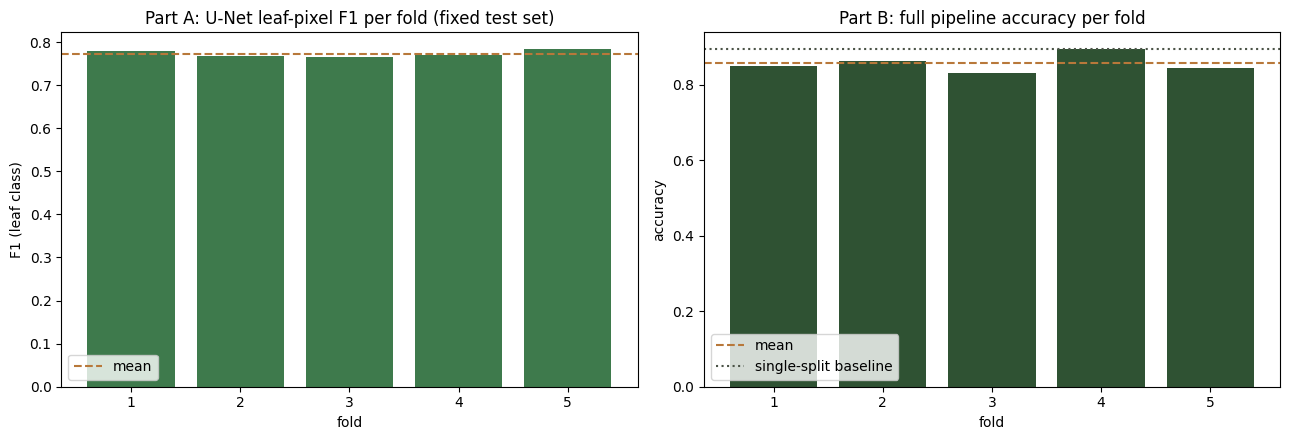

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(seg_cv_df["fold"] + 1, seg_cv_df["test_leaf_f1"], color="#3E7A4C")
axes[0].axhline(seg_cv_df["test_leaf_f1"].mean(), color="#B8783A", linestyle="--", label="mean")
axes[0].set_title("Part A: U-Net leaf-pixel F1 per fold (fixed test set)")
axes[0].set_xlabel("fold")
axes[0].set_ylabel("F1 (leaf class)")
axes[0].legend()

axes[1].bar(pipeline_cv_df["fold"] + 1, pipeline_cv_df["accuracy"], color="#2F5233")
axes[1].axhline(pipeline_cv_df["accuracy"].mean(), color="#B8783A", linestyle="--", label="mean")
axes[1].axhline(0.8938, color="#4B5347", linestyle=":", label="single-split baseline")
axes[1].set_title("Part B: full pipeline accuracy per fold")
axes[1].set_xlabel("fold")
axes[1].set_ylabel("accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(CV_OUTPUT_DIR, "cv_summary.png"), dpi=150)
plt.show()


## Notes on interpreting these results

- **Part A's fixed-test-set numbers are the ones to compare across folds** — the val-subset
  numbers use a *different* held-out set each fold, so they're not directly comparable to
  each other the way the fixed-test-set numbers are.
- A wide std across folds in Part A means U-Net's segmentation quality is sensitive to which
  images it trains on — a narrow std means it's stable regardless of split, similar in spirit
  to the ResNet50 branch's own 5-fold CV finding (mean 94.25% ± 3.39%, single-split 96.88%).
- Part B isolates the segmenter's contribution: since the classifier never changes, any
  spread in Part B's pipeline accuracy across folds is attributable to U-Net's fold-to-fold
  variation, not the classifier's.
- `EPOCHS_PER_FOLD=15` is a runtime/rigor tradeoff, not a scientific choice — if fold results
  look unstable or a fold's val Dice is still climbing at the last epoch, increase it (the
  main pipeline uses 60) at the cost of proportionally longer runtime.
